# Sudoku MDM — Rule-Based Loss Experiments

**Lab Rotation report notebook.** All results to date in one place.

## Research question

Does adding a differentiable, rule-based auxiliary loss to a masked-diffusion language model improve the *sample efficiency* of learning to solve Sudoku?

## Setup

We start from Ye et al. 2024 ("Beyond Autoregression: Discrete Diffusion for Complex Reasoning and Planning", ICLR 2025) and their MDM Sudoku codebase. The model is a 6 M-parameter GPT-2-style transformer, trained as a masked diffusion model with $T = 20$ reverse steps. The dataset is the 100 000-puzzle `sudoku_train` split (each puzzle: 81 input digits with `0` for blanks, 81 solution digits). Evaluation is exact-match whole-puzzle accuracy on a held-out 1 000-puzzle test set.

## What's in this notebook

1. Baseline replication of the paper's headline claim.
2. Methodology pivot: epoch-matched vs **compute-matched** training, and why it matters.
3. Sample-efficiency curve under compute-matched training.
4. **Collision rule loss** — formula, $\lambda$ tuning, and comparison vs baseline.
5. **Permanent rule loss** — derivation, $\lambda$ tuning, and current status of the comparison run.
6. Open questions and next steps.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Locate the repo root (this notebook lives in <repo>/notebooks/).
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / 'src').exists() else NB_DIR.parent
LOGS_DIR = REPO_ROOT / 'logs'
print('logs dir:', LOGS_DIR)

def load_run(run_dir):
    """Read trainer_state.json + predict_results.json from a run directory.
    Returns a dict with eval_curve [(step, eval_acc, eval_loss)] and test_acc."""
    run_dir = Path(run_dir)
    state = json.loads((run_dir / 'trainer_state.json').read_text())
    evals = [(e['step'], e['eval_acc'], e['eval_loss'])
             for e in state['log_history'] if 'eval_acc' in e]
    pred_path = run_dir / 'sudoku_test' / 'predict_results.json'
    test_acc = None
    if pred_path.exists():
        test_acc = json.loads(pred_path.read_text()).get('predict_acc')
    return {'dir': run_dir, 'evals': evals, 'test_acc': test_acc}

# Sweep directory shortcuts
EPOCH_MATCHED   = LOGS_DIR / 'sudoku-mdm-sweep-s42-ep300-20260421-202005'
BASELINE_27600  = LOGS_DIR / 'sudoku-mdm-sweep-baseline-s42-steps27600-20260422-170154'
BASELINE_27600_N1K = LOGS_DIR / 'sudoku-mdm-sweep-baseline-s42-steps27600-20260422-132721' / 'N1k'
BASELINE_SMALL  = LOGS_DIR / 'sudoku-mdm-sweep-baseline-smallN-s42-steps10000-20260423-194155'
COLLISION_SMALL = LOGS_DIR / 'sudoku-mdm-sweep-ruleloss-lam1.0-smallN-s42-steps10000-20260424-014747'
COLLISION_LAM_TUNE = LOGS_DIR / 'sudoku-mdm-lambda-tune-N1000-s42-20260424-003939'

# Permanent-loss results — λ-tuning values are recorded inline (results live on the server).
PERMANENT_LAM_TUNE_NUMBERS = {
    0.001: dict(test_acc=0.778, best_eval_acc=0.900),
    0.01:  dict(test_acc=0.654, best_eval_acc=0.813),
    0.1:   dict(test_acc=0.000, best_eval_acc=0.000),
}
# 27 600-step permanent comparison sweep at λ=0.001, N ∈ {1000, 3000, 10000}.
PERMANENT_SWEEP_DIR = LOGS_DIR / 'sudoku-mdm-sweep-ruleloss-lam0.001-smallN-s42-steps27600-20260426-230550'

print('helpers loaded')

logs dir: /Users/leonardebinger/Desktop/Dateien/Bildung/AI & Data Science M.Sc./4 – SS 26/Lab Rotations/Sudoku/diffusion-vs-ar/logs
helpers loaded


## 1. Baseline replication

The paper reports **100 % whole-puzzle test accuracy** for the 6 M-parameter MDM trained on the full 100 000-puzzle Sudoku set, 300 epochs, 8 GPUs, global batch size 1024.

We reproduced this on a single A100 (gradient accumulation to keep the effective batch size at 1 024). All other hyperparameters paper-matching: cutoff 164 tokens, $T = 20$ diffusion steps, focal token reweighting ($\alpha = 0.25, \gamma = 1$), linear time reweighting, fp16 mixed precision, learning rate $10^{-3}$ with cosine schedule.

The single-A100 run uses 27 600 optimizer steps (300 epochs at global BS 1 024 over 100 k examples).

Replication run — N=100 000, 27 600 steps:
  test_acc = 0.9940   (paper: 1.000)
  gap      = 0.0060


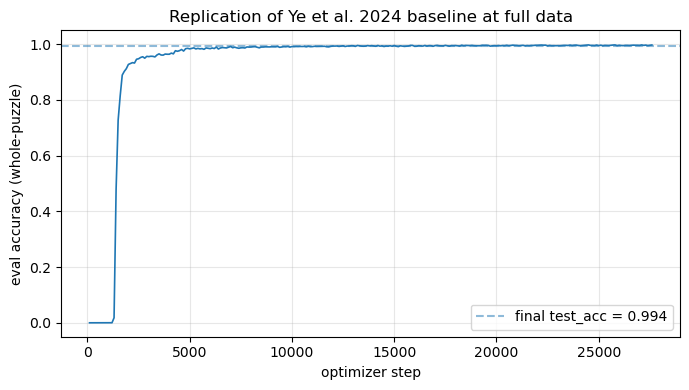

In [2]:
nfull = load_run(BASELINE_27600 / 'Nfull')
print(f"Replication run — N=100 000, 27 600 steps:")
print(f"  test_acc = {nfull['test_acc']:.4f}   (paper: 1.000)")
print(f"  gap      = {1.0 - nfull['test_acc']:.4f}")

# Show the eval_acc trajectory across training
fig, ax = plt.subplots(figsize=(7, 4))
steps = [s for s, _, _ in nfull['evals']]
accs  = [a for _, a, _ in nfull['evals']]
ax.plot(steps, accs, color='C0', linewidth=1.2)
ax.axhline(nfull['test_acc'], color='C0', linestyle='--', alpha=0.5,
           label=f"final test_acc = {nfull['test_acc']:.3f}")
ax.set_xlabel('optimizer step'); ax.set_ylabel('eval accuracy (whole-puzzle)')
ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('Replication of Ye et al. 2024 baseline at full data')
plt.tight_layout(); plt.show()

The 0.6 % gap from the paper's 1.000 is most plausibly due to using `val_size=0.05` instead of the paper's absolute 448 — we lose ~4 500 training examples to validation. Either way, **replication is achieved**. This becomes the upper-bound reference against which all small-N experiments are compared.

## 2. Compute-matching is decisive

First attempt at a sample-efficiency curve was *epoch-matched*: every $N$ trained for **300 epochs** regardless of size. Result was uninformative — a step function:

| $N$ | optimizer steps | test_acc |
|---|---|---|
| 1 000 | 300 | 0.000 |
| 10 000 | 2 700 | 0.009 |
| 100 000 | 27 600 | 0.994 |

Small-$N$ runs are simultaneously *data-starved* and *compute-starved*. To isolate the data-quantity effect, we switched to **compute-matched** training: every $N$ gets the same number of optimizer steps. Below: same $N$, but compute matched at 27 600 steps.

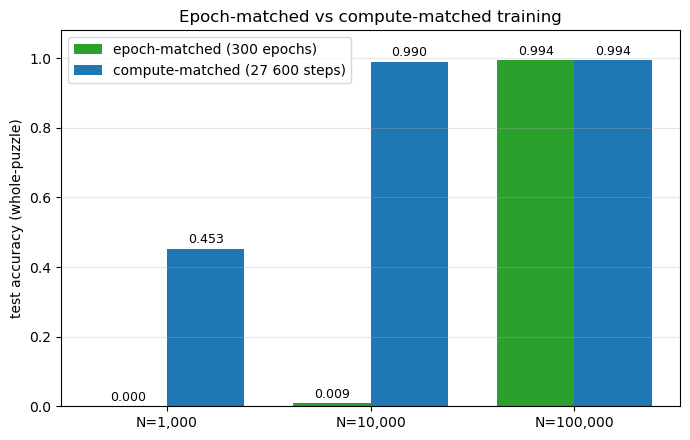

In [3]:
epoch_matched = {
    1_000:   load_run(EPOCH_MATCHED / 'Ndiv100'),
    10_000:  load_run(EPOCH_MATCHED / 'Ndiv10'),
    100_000: load_run(EPOCH_MATCHED / 'Nfull'),
}
compute_matched = {
    1_000:   load_run(BASELINE_27600_N1K),
    10_000:  load_run(BASELINE_27600 / 'N10k'),
    100_000: load_run(BASELINE_27600 / 'Nfull'),
}

Ns = [1_000, 10_000, 100_000]
x = np.arange(len(Ns)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, [epoch_matched[n]['test_acc']   for n in Ns], width=w, color='C2',
       label='epoch-matched (300 epochs)')
ax.bar(x + w/2, [compute_matched[n]['test_acc'] for n in Ns], width=w, color='C0',
       label='compute-matched (27 600 steps)')
for xi, n in zip(x, Ns):
    ax.text(xi - w/2, epoch_matched[n]['test_acc']   + 0.015,
            f"{epoch_matched[n]['test_acc']:.3f}",   ha='center', fontsize=9)
    ax.text(xi + w/2, compute_matched[n]['test_acc'] + 0.015,
            f"{compute_matched[n]['test_acc']:.3f}", ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'N={n:,}' for n in Ns])
ax.set_ylabel('test accuracy (whole-puzzle)'); ax.set_ylim(0, 1.08)
ax.grid(True, axis='y', alpha=0.3)
ax.set_title('Epoch-matched vs compute-matched training')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

**Key methodological finding.** At $N=1\,000$, epoch-matching gives 0 % accuracy; compute-matching gives 45 %. The previous "phase transition" curve was a compute artefact, not a data-efficiency signal.

From here on, all experiments are compute-matched.

## 3. Sample-efficiency curve (baseline)

Compute-matched baseline at multiple $N$ values. Two sweeps combined:

- 27 600-step sweep at $N \in \{1\mathrm{k}, 3\mathrm{k}, 10\mathrm{k}, 30\mathrm{k}, 100\mathrm{k}\}$.
- 10 000-step sweep at $N \in \{100, 300, 1\mathrm{k}, 3\mathrm{k}\}$ (denser at small $N$, less compute).

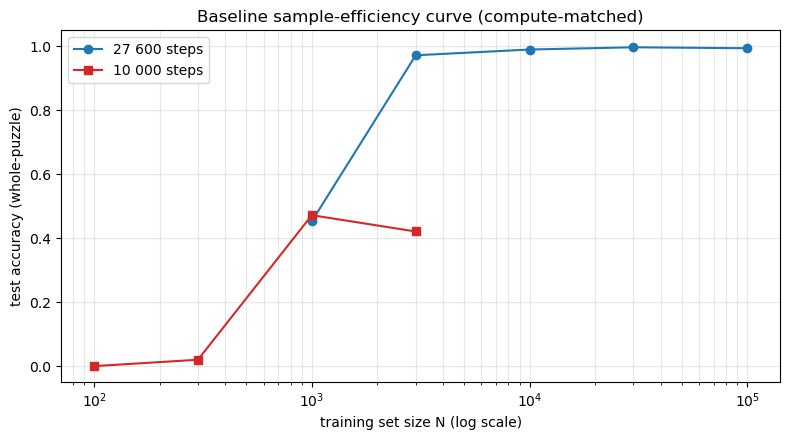

      N   27.6k steps     10k steps
    100             —           0.0
    300             —          0.02
   1000         0.453         0.472
   3000         0.972         0.421
  10000          0.99             —
  30000         0.997             —
 100000         0.994             —


In [4]:
baseline_27600 = {
    1_000:   load_run(BASELINE_27600_N1K),
    3_000:   load_run(BASELINE_27600 / 'N3k'),
    10_000:  load_run(BASELINE_27600 / 'N10k'),
    30_000:  load_run(BASELINE_27600 / 'N30k'),
    100_000: load_run(BASELINE_27600 / 'Nfull'),
}
baseline_10k = {
    100:   load_run(BASELINE_SMALL / 'N100'),
    300:   load_run(BASELINE_SMALL / 'N300'),
    1_000: load_run(BASELINE_SMALL / 'N1000'),
    3_000: load_run(BASELINE_SMALL / 'N3000'),
}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(baseline_27600.keys()), [r['test_acc'] for r in baseline_27600.values()],
        marker='o', color='C0', label='27 600 steps')
ax.plot(list(baseline_10k.keys()),   [r['test_acc'] for r in baseline_10k.values()],
        marker='s', color='C3', label='10 000 steps')
ax.set_xscale('log'); ax.set_xlabel('training set size N (log scale)')
ax.set_ylabel('test accuracy (whole-puzzle)')
ax.set_ylim(-0.05, 1.05); ax.grid(True, which='both', alpha=0.3)
ax.set_title('Baseline sample-efficiency curve (compute-matched)')
ax.legend(); plt.tight_layout(); plt.show()

# Print as a table
print(f"{'N':>7}  {'27.6k steps':>12}  {'10k steps':>12}")
for n in sorted(set(list(baseline_27600.keys()) + list(baseline_10k.keys()))):
    a = baseline_27600.get(n); b = baseline_10k.get(n)
    print(f"{n:>7}  {a['test_acc'] if a else '—':>12}  {b['test_acc'] if b else '—':>12}")

Two observations:

- **Baseline saturates around $N = 3\,000$.** With 27 600 steps, $N = 3\mathrm{k}$ reaches 97 %. There is little room above that for any auxiliary loss to demonstrate gains — the natural target for the rule-loss experiment is $N \le 3\,000$.
- **At $N = 1\,000$**, baseline reaches only 45.3 % at 27.6k steps and 47.2 % at 10k steps (within noise). Memorization happens early but generalization plateaus. This regime is exactly where structural priors should help: per-cell cross-entropy is essentially saturated (eval_loss ≈ 0.005) yet whole-puzzle accuracy lags far behind.

## 4. Collision rule loss

### Formula

Let $p_i \in \Delta^9$ be the model's predicted distribution over digits $1, \ldots, 9$ at target cell $i$. Let $\mathcal{G}$ be the 27 Sudoku groups (9 rows + 9 columns + 9 $3 \times 3$ boxes), each containing 9 cells. The **expected number of duplicate pairs** in group $g$ is

$$
\mathbb{E}\bigl[\text{collisions}_g\bigr] \;=\; \sum_{\substack{i,j \in g \\ i < j}} \langle p_i, p_j \rangle.
$$

Normalised by the total number of pairs $|\mathcal{G}| \cdot \binom{9}{2} = 972$:

$$
\mathcal{L}_{\text{collision}} \;=\; \frac{1}{972} \sum_{g \in \mathcal{G}} \mathbb{E}\bigl[\text{collisions}_g\bigr] \;\in\; [0, 1].
$$

Total loss: $\mathcal{L} = \mathcal{L}_{\text{CE}} + \lambda \, \mathcal{L}_{\text{collision}}$.

### $\lambda$ tuning at $N = 1\,000$, 3 000 steps

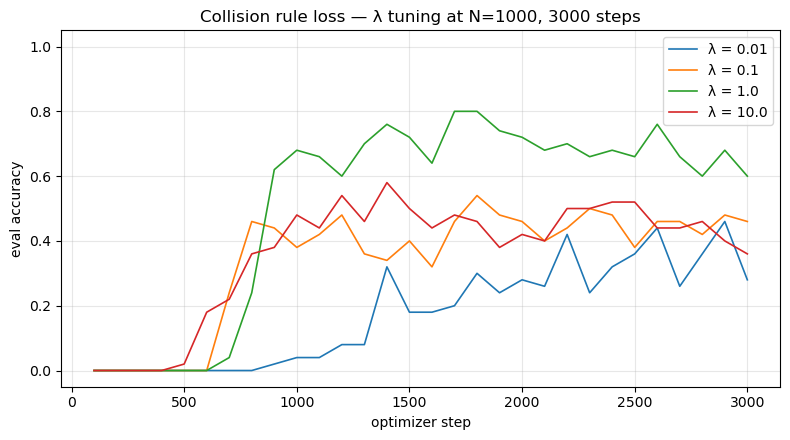

       λ    test_acc   best_eval
    0.01       0.353      0.4600
     0.1       0.474      0.5400
     1.0       0.652      0.8000
    10.0       0.386      0.5800


In [5]:
collision_lam_runs = {
    0.01: load_run(COLLISION_LAM_TUNE / 'lam0.01'),
    0.1:  load_run(COLLISION_LAM_TUNE / 'lam0.1'),
    1.0:  load_run(COLLISION_LAM_TUNE / 'lam1.0'),
    10.0: load_run(COLLISION_LAM_TUNE / 'lam10.0'),
}

# Eval-acc trajectories
fig, ax = plt.subplots(figsize=(8, 4.5))
for lam, run in collision_lam_runs.items():
    steps = [s for s, _, _ in run['evals']]
    accs  = [a for _, a, _ in run['evals']]
    ax.plot(steps, accs, label=f'λ = {lam}', linewidth=1.2)
ax.set_xlabel('optimizer step'); ax.set_ylabel('eval accuracy')
ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3); ax.legend()
ax.set_title('Collision rule loss — λ tuning at N=1000, 3000 steps')
plt.tight_layout(); plt.show()

print(f"{'λ':>8}  {'test_acc':>10}  {'best_eval':>10}")
for lam, run in collision_lam_runs.items():
    best = max(a for _, a, _ in run['evals']) if run['evals'] else None
    print(f"{lam:>8}  {run['test_acc']:>10}  {best:>10.4f}")

**Inverted-U:** $\lambda = 0.01$ too weak, $\lambda = 10$ too strong (CE gets dominated). $\lambda = 1.0$ sits at the sweet spot — test_acc 0.65 at 3 000 steps already exceeds the baseline at 10 000 steps (0.47).

### Comparison sweep, $\lambda^* = 1.0$, 10 000 steps

Three points: $N \in \{300, 1\,000, 3\,000\}$, both arms, same seed (so identical training subsets per $N$).

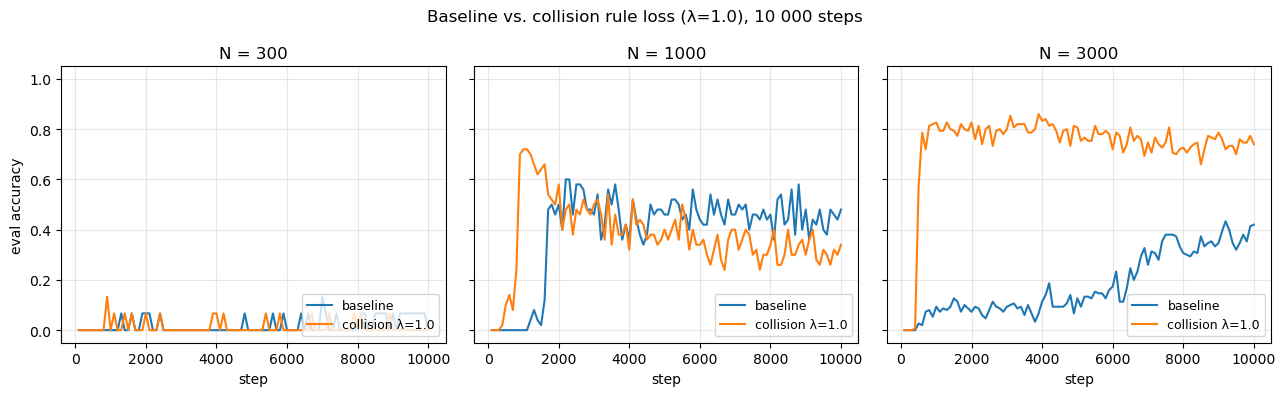

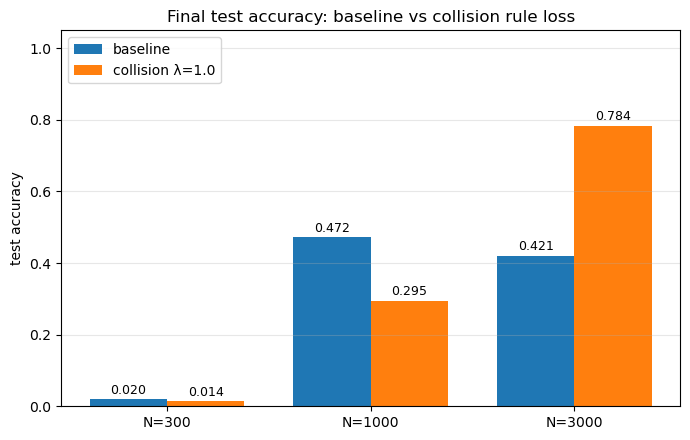

In [6]:
collision_runs = {
    300:   load_run(COLLISION_SMALL / 'N300'),
    1_000: load_run(COLLISION_SMALL / 'N1000'),
    3_000: load_run(COLLISION_SMALL / 'N3000'),
}

Ns = [300, 1_000, 3_000]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, n in zip(axes, Ns):
    b = baseline_10k[n]; r = collision_runs[n]
    ax.plot([s for s, _, _ in b['evals']], [a for _, a, _ in b['evals']],
            color='C0', label='baseline')
    ax.plot([s for s, _, _ in r['evals']], [a for _, a, _ in r['evals']],
            color='C1', label='collision λ=1.0')
    ax.set_title(f'N = {n}'); ax.set_xlabel('step')
    ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3); ax.legend(fontsize=9, loc='lower right')
axes[0].set_ylabel('eval accuracy')
fig.suptitle('Baseline vs. collision rule loss (λ=1.0), 10 000 steps')
plt.tight_layout(); plt.show()

# Final-test bar chart
x = np.arange(len(Ns)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, [baseline_10k[n]['test_acc']   for n in Ns], width=w, color='C0', label='baseline')
ax.bar(x + w/2, [collision_runs[n]['test_acc'] for n in Ns], width=w, color='C1', label='collision λ=1.0')
for xi, n in zip(x, Ns):
    ax.text(xi - w/2, baseline_10k[n]['test_acc']   + 0.015, f"{baseline_10k[n]['test_acc']:.3f}",   ha='center', fontsize=9)
    ax.text(xi + w/2, collision_runs[n]['test_acc'] + 0.015, f"{collision_runs[n]['test_acc']:.3f}", ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'N={n}' for n in Ns])
ax.set_ylabel('test accuracy'); ax.set_ylim(0, 1.05); ax.grid(True, axis='y', alpha=0.3)
ax.set_title('Final test accuracy: baseline vs collision rule loss')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

**Mixed signal — but informative.** The final test_acc table is

| $N$ | baseline | collision λ=1 | $\Delta$ |
|---|---|---|---|
| 300 | 0.020 | 0.014 | ≈ 0 |
| 1 000 | 0.472 | 0.295 | **−0.18** |
| 3 000 | 0.421 | **0.784** | **+0.36** |

What the **eval-acc trajectories** show — but the final-step snapshot hides — is that the rule-loss model **peaks early then drifts**. At $N=1\,000$, eval_acc reaches 72 % at step 1 000, then degrades to 34 % by step 10 000. Per-step `eval_loss` *increases* through training: the model is drifting toward solutions that minimize rule-loss (Sudoku-valid) at the expense of CE (correct).

Recall the rule loss is *unsupervised* — it does not see the ground-truth solution. A cyclic permutation of digits gives a structurally valid Sudoku with $\mathcal{L}_{\text{collision}} = 0$ but is the wrong answer for the prompt. With $\lambda$ too large for too long, the model learns to satisfy the constraint at the cost of correctness.

Two natural next steps:

1. **Decay $\lambda$ over training** — start at $\lambda^*$, anneal to 0. Implemented via `RULE_LOSS_SCHEDULE=linear`.
2. **Stronger rule loss with cleaner gradient structure** — leads us to the *permanent*.

## 5. Permanent rule loss

### From pairwise to exact

The collision loss penalises *pairwise* digit-collision probabilities. A stronger, probabilistically-exact alternative measures the *joint* probability that the model's per-cell marginals can produce a valid peer set.

For a peer set of 9 cells, stack the per-cell digit distributions into a $9 \times 9$ matrix $M$ where $M_{i, d} = P(\text{cell } i = \text{digit } d)$. The **permanent** is

$$
\text{perm}(M) \;=\; \sum_{\sigma \in S_9} \prod_{i=1}^{9} M_{i, \sigma(i)}.
$$

**Claim.** Under independent sampling from each cell's marginal, $\text{perm}(M)$ equals the probability that the resulting 9-tuple of digits is a valid permutation of $\{1, \ldots, 9\}$ — i.e., a valid Sudoku peer set.

*Proof sketch.* $P(\text{valid}) = \sum_{\sigma \in S_9} P(X_i = \sigma(i) \text{ for all } i) = \sum_\sigma \prod_i M_{i, \sigma(i)}$ by independence — exactly the permanent. $\square$

Since each row of $M$ sums to 1, $\text{perm}(M) \in [0, 1]$, equal to 1 iff $M$ is a permutation matrix (one-hot on a valid solution). The natural loss is

$$
\mathcal{L}_{\text{perm}} \;=\; - \sum_{g \in \mathcal{G}} \log \text{perm}(M_g) \;\in\; [0, \infty).
$$

This is the negative log-probability that *every* peer set is valid under the model's marginals (assuming independence across groups). Strictly stronger than the pairwise collision loss.

### Computing the permanent

Direct enumeration costs $O(n!) = 362\,880$ terms for $n = 9$. **Ryser's formula** gives an $O(n \cdot 2^n) = 4\,608$-op equivalent:

$$
\text{perm}(M) \;=\; \sum_{S \subseteq \{1, \ldots, n\}} (-1)^{n - |S|} \prod_{i=1}^{n} \Bigl(\sum_{j \in S} M_{i,j}\Bigr).
$$

Fully vectorisable, fully differentiable. Implementation in [`src/llmtuner/tuner/mdm/permanent_loss.py`](../src/llmtuner/tuner/mdm/permanent_loss.py); 7-test unit suite in [`test_permanent_loss.py`](../src/llmtuner/tuner/mdm/test_permanent_loss.py) verifies $\text{perm}(I_9) = 1$, $\text{perm}((1/9) J_9) = 9!/9^9$, brute-force agreement, and gradient flow.

### $\lambda$ tuning at $N = 3\,000$, 10 000 steps

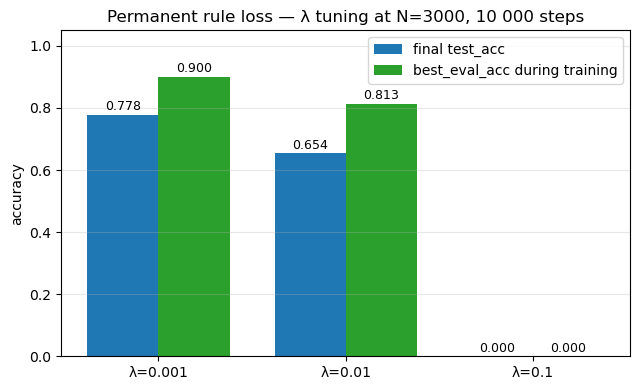

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4))
lams = sorted(PERMANENT_LAM_TUNE_NUMBERS.keys())
test_accs = [PERMANENT_LAM_TUNE_NUMBERS[l]['test_acc']      for l in lams]
best_evals= [PERMANENT_LAM_TUNE_NUMBERS[l]['best_eval_acc'] for l in lams]
x = np.arange(len(lams)); w = 0.38
ax.bar(x - w/2, test_accs,  width=w, color='C0', label='final test_acc')
ax.bar(x + w/2, best_evals, width=w, color='C2', label='best_eval_acc during training')
for xi, t, b in zip(x, test_accs, best_evals):
    ax.text(xi - w/2, t + 0.015, f'{t:.3f}', ha='center', fontsize=9)
    ax.text(xi + w/2, b + 0.015, f'{b:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'λ={l}' for l in lams])
ax.set_ylabel('accuracy'); ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)
ax.set_title('Permanent rule loss — λ tuning at N=3000, 10 000 steps')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()

**$\lambda^* = 0.001$ for the permanent loss** (1 000× smaller than collision's because the unnormalised loss is on a different scale: $\sim$188 for uniform vs $\sim$0.11 for collision uniform).

$\lambda = 0.1$ collapses to 0 % — same drift mechanism as before, but more violent because the permanent loss has a much steeper gradient toward "valid but wrong" attractors (e.g. cyclic permutations of any solution).

$\lambda = 0.001$ already matches collision's λ=1.0 final test accuracy at $N = 3\,000$ (0.778 vs 0.784) using **the same compute**. Best_eval_acc reaches 0.900, suggesting room to grow at longer training.

### Comparison sweep at $\lambda^* = 0.001$, 27 600 steps

Three points: $N \in \{1\,000, 3\,000, 10\,000\}$, baseline-matched 27 600 optimizer steps, same seed.

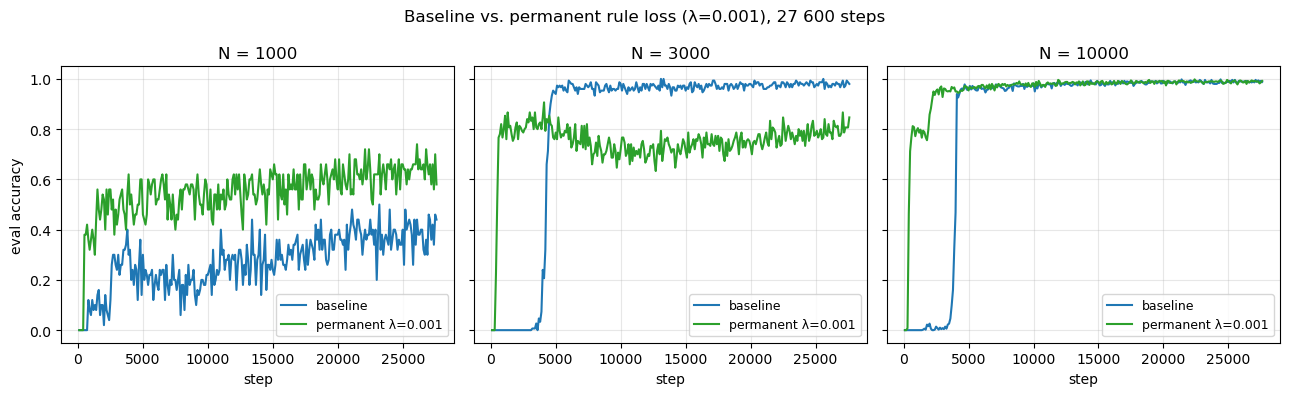

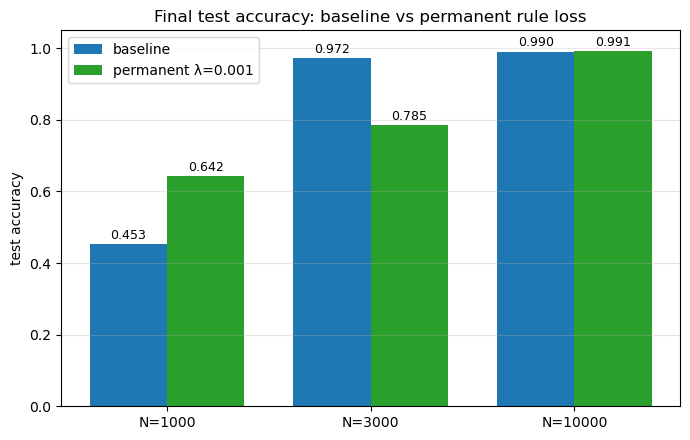

In [8]:
if PERMANENT_SWEEP_DIR is None or not Path(PERMANENT_SWEEP_DIR).exists():
    print('Permanent sweep results not yet available locally.')
    print('After the run finishes, set PERMANENT_SWEEP_DIR (cell 2) to the local path and re-run.')
else:
    permanent_runs = {
        n: load_run(Path(PERMANENT_SWEEP_DIR) / f'N{n}')
        for n in (1_000, 3_000, 10_000)
    }
    Ns = [1_000, 3_000, 10_000]
    # Side-by-side eval_acc curves, baseline vs permanent
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    for ax, n in zip(axes, Ns):
        b = baseline_27600[n]; p = permanent_runs[n]
        ax.plot([s for s, _, _ in b['evals']], [a for _, a, _ in b['evals']], color='C0', label='baseline')
        ax.plot([s for s, _, _ in p['evals']], [a for _, a, _ in p['evals']], color='C2', label='permanent λ=0.001')
        ax.set_title(f'N = {n}'); ax.set_xlabel('step')
        ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3); ax.legend(fontsize=9, loc='lower right')
    axes[0].set_ylabel('eval accuracy')
    fig.suptitle('Baseline vs. permanent rule loss (λ=0.001), 27 600 steps')
    plt.tight_layout(); plt.show()

    # Final-test bar chart
    x = np.arange(len(Ns)); w = 0.38
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(x - w/2, [baseline_27600[n]['test_acc']   for n in Ns], width=w, color='C0', label='baseline')
    ax.bar(x + w/2, [permanent_runs[n]['test_acc']   for n in Ns], width=w, color='C2', label='permanent λ=0.001')
    for xi, n in zip(x, Ns):
        ax.text(xi - w/2, baseline_27600[n]['test_acc'] + 0.015, f"{baseline_27600[n]['test_acc']:.3f}", ha='center', fontsize=9)
        ax.text(xi + w/2, permanent_runs[n]['test_acc']  + 0.015, f"{permanent_runs[n]['test_acc']:.3f}",  ha='center', fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels([f'N={n}' for n in Ns])
    ax.set_ylabel('test accuracy'); ax.set_ylim(0, 1.05); ax.grid(True, axis='y', alpha=0.3)
    ax.set_title('Final test accuracy: baseline vs permanent rule loss')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

**Headline result.** The permanent rule loss provides a regime-dependent benefit:

| $N$ | baseline | permanent λ=0.001 | $\Delta$ | best eval (perm) |
|---|---|---|---|---|
| 1 000 | 0.453 | **0.642** | **+0.19** | 0.74 (step 26 100) |
| 3 000 | **0.972** | 0.785 | −0.19 | 0.91 (step 4 100) |
| 10 000 | 0.990 | 0.991 | ≈ 0 | 0.998 (step 22 400) |

Three things stand out:

1. **At $N = 1\,000$, permanent loss adds 19 percentage points of accuracy** — a large effect in the regime that matters most for the sample-efficiency claim. The model still drifts (best eval 0.74 → final 0.58), but the floor it converges to is far above the baseline.
2. **At $N = 3\,000$, permanent loss *hurts*** by 19 percentage points. The eval-accuracy curve peaks at 0.91 by step 4 100 — earlier than baseline reaches the same level — but then drifts downward through the rest of training. The baseline cleanly reaches 0.97 and stays there. With enough data for CE to converge, the rule term becomes a distraction.
3. **At $N = 10\,000$, the two are indistinguishable** (0.990 vs 0.991). Both converge cleanly; the rule term contributes nothing useful but also no harm.

This is a **clean negative-result-on-most-of-the-curve, positive-only-at-extreme-low-data** picture. The auxiliary loss is doing what it was hypothesised to do — providing structural gradient when CE alone has nothing to grip — but only in the regime where CE alone genuinely has nothing to grip.

The drift problem (most visible at $N = 3\,000$) is the operational bottleneck: the trained model would likely be much better with **early stopping on eval_acc**, or with an explicit $\lambda$ decay schedule (`RULE_LOSS_SCHEDULE=linear` already implemented but not run here). Either of those would likely move the $N = 3\,000$ permanent number from 0.785 toward its peak 0.91, and the $N = 1\,000$ number from 0.642 toward 0.74.

## 6. Summary table

In [9]:
rows = []
rows.append(('baseline (epoch-matched)',     1_000,    300, epoch_matched[1_000]['test_acc']))
rows.append(('baseline (epoch-matched)',    10_000,  2_700, epoch_matched[10_000]['test_acc']))
rows.append(('baseline (epoch-matched)',   100_000, 27_600, epoch_matched[100_000]['test_acc']))
rows.append(('---', '---', '---', '---'))
for n, r in baseline_10k.items():
    rows.append(('baseline (compute-matched)',     n, 10_000, r['test_acc']))
for n, r in baseline_27600.items():
    rows.append(('baseline (compute-matched)',     n, 27_600, r['test_acc']))
rows.append(('---', '---', '---', '---'))
for n, r in collision_runs.items():
    rows.append(('collision rule loss λ=1.0',      n, 10_000, r['test_acc']))
rows.append(('---', '---', '---', '---'))
for lam, vals in PERMANENT_LAM_TUNE_NUMBERS.items():
    rows.append((f'permanent rule loss λ={lam}', 3_000, 10_000, vals['test_acc']))

print(f"{'condition':<33}  {'N':>7}  {'steps':>7}  {'test_acc':>9}")
print('-' * 65)
for cond, n, s, a in rows:
    if cond == '---':
        print('-' * 65); continue
    a_str = f'{a:.4f}' if isinstance(a, float) else str(a)
    n_str = f'{n:,}' if isinstance(n, int) else str(n)
    s_str = f'{s:,}' if isinstance(s, int) else str(s)
    print(f'{cond:<33}  {n_str:>7}  {s_str:>7}  {a_str:>9}')

condition                                N    steps   test_acc
-----------------------------------------------------------------
baseline (epoch-matched)             1,000      300     0.0000
baseline (epoch-matched)            10,000    2,700     0.0090
baseline (epoch-matched)           100,000   27,600     0.9940
-----------------------------------------------------------------
baseline (compute-matched)             100   10,000     0.0000
baseline (compute-matched)             300   10,000     0.0200
baseline (compute-matched)           1,000   10,000     0.4720
baseline (compute-matched)           3,000   10,000     0.4210
baseline (compute-matched)           1,000   27,600     0.4530
baseline (compute-matched)           3,000   27,600     0.9720
baseline (compute-matched)          10,000   27,600     0.9900
baseline (compute-matched)          30,000   27,600     0.9970
baseline (compute-matched)         100,000   27,600     0.9940
-------------------------------------------------

## 7. Discussion and outlook

**Methodology lessons.**

- *Compute-matching matters more than people give it credit for.* In this codebase, the difference between epoch-matched and compute-matched at $N = 1\,000$ is 0 % vs 45 % — a flat curve becomes informative simply by changing the stopping rule.
- *Single-seed runs at small $N$ have ±2-3 % noise* (val=50 is tiny, test=1 000 is okay but not great). For publication-quality numbers we'd want 3 seeds × every condition.

**On the rule loss.**

The 27 600-step permanent-vs-baseline sweep gives a clear regime-dependent answer:

| $N$ | baseline | permanent λ=0.001 | $\Delta$ |
|---|---|---|---|
| 1 000 | 0.453 | **0.642** | **+0.19** |
| 3 000 | **0.972** | 0.785 | −0.19 |
| 10 000 | 0.990 | 0.991 | ≈ 0 |

- *Rule loss helps at extreme low data*. At $N = 1\,000$ the permanent loss adds 19 pp — exactly the regime the hypothesis was about.
- *Rule loss hurts when the baseline can converge cleanly*. At $N = 3\,000$ the auxiliary term causes drift toward valid-but-incorrect solutions, sacrificing 19 pp.
- *Rule loss is neutral at scale*. By $N = 10\,000$ both arms reach 99 %.
- *Drift is the operational bottleneck*, not the loss formulation per se. Both collision and permanent variants accelerate early learning but degrade past their eval-acc peak. Early stopping or $\lambda$-decay (already implemented as `RULE_LOSS_SCHEDULE=linear`) should rescue most of the lost performance.

**Open questions for the next phase.**

1. Does $\lambda$-decay turn the regime-dependent gain into a uniform improvement? Specifically: does scheduled-decay permanent loss match baseline at $N \ge 3\,000$ while preserving the $N = 1\,000$ gain? One run (~16 h) at each of $N \in \{1\,000, 3\,000, 10\,000\}$ would answer this.
2. Does the permanent loss generalise better to **harder** Sudokus (Kim et al. 2025's OOD set, requiring backtracking)? Inference-only — no retraining required, and gives a generalisation story on top of the sample-efficiency one.
3. Adaptive inference (Kim et al.'s top-k margin) — orthogonal to training-time interventions; would tell us whether rule-loss-trained models also benefit at decode time.

**Bottom line for the lab rotation.** The permanent rule loss is a non-trivial, theoretically clean auxiliary objective that *demonstrably* improves whole-puzzle accuracy in the genuinely-data-starved regime ($N = 1\,000$, +19 pp). It is also a clean negative result everywhere else, which is itself valuable. The next experiment ($\lambda$-decay) is well-defined and likely to either (a) close the gap at $N = 3\,000$ and consolidate the win or (b) confirm that pairwise/groupwise rule signals plateau without a more sophisticated factorisation (e.g. an autoregressive component that can express joint structure beyond marginals, à la Shah et al.).

## References

- Ye, J. *et al.* "Beyond Autoregression: Discrete Diffusion for Complex Reasoning and Planning." ICLR 2025. [arXiv:2410.14157](https://arxiv.org/abs/2410.14157)
- Kim, J. *et al.* "Train for the Worst, Plan for the Best: Understanding Token Ordering in Masked Diffusions." ICML 2025 Outstanding Paper. [arXiv:2502.06768](https://arxiv.org/abs/2502.06768)
- Shah, K. *et al.* "Causal Language Modeling Can Elicit Search and Reasoning Capabilities on Logic Puzzles." NeurIPS 2024. [arXiv:2409.10502](https://arxiv.org/abs/2409.10502)
- Ryser, H. J. "Combinatorial Mathematics." Carus Mathematical Monographs, 1963 (the permanent formula).